# Driving pulses

Shape the ultrasound that drives a bubble. You compare carrier shapes, combine pulses with arithmetic, sweep the frequency with a chirp, and load a pressure trace measured on a hydrophone. Then you drive the same bubble with the chirp and with the measured trace.

A pulse is a function of time: `pulse(t)` returns the pressure in pascals. Every pulse is a JAX-compatible module, so you can evaluate it with `jax.vmap` and differentiate through it.

In [ ]:
# Install jbubble on Google Colab, or anywhere it's missing.
import importlib.util

if importlib.util.find_spec("jbubble") is None:
    %pip install --quiet "jbubble[examples]==0.2.0"

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from jbubble import SaveSpec, run_simulation
from jbubble.pulse import ChirpPulse, HannEnvelope, SampledPulse, ToneBurst
from jbubble.pulse.shapes import Sawtooth, Sine, Square, Triangle
from jbubble.utils.presets import free_bubble

plt.style.use("jbubble.style.light")
DRIVE = "#8c959f"  # neutral grey for the acoustic drive in the light theme

## Choose a carrier shape

A `ToneBurst` multiplies a periodic carrier shape by a peak pressure and an envelope. It lasts `cycle_num / freq` seconds. The square, sawtooth, and triangle shapes sum the first 10 terms of their Fourier series, which keeps them smooth enough to differentiate, at the cost of a small ripple near each jump.

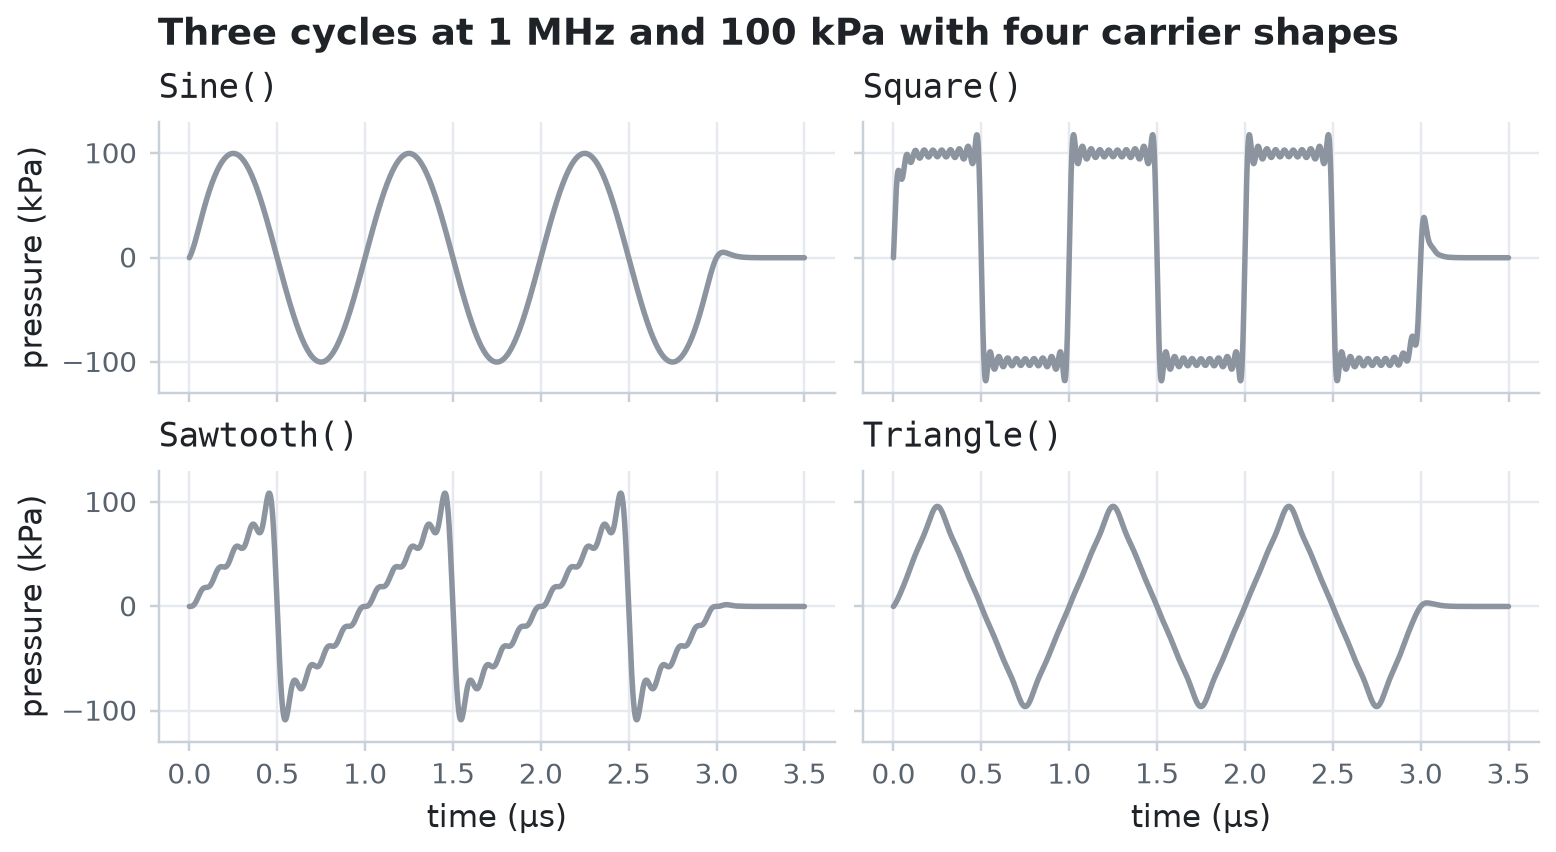

In [2]:
ts = jnp.linspace(0.0, 3.5e-6, 1500)
shapes = {
    "Sine()": Sine(),
    "Square()": Square(),
    "Sawtooth()": Sawtooth(),
    "Triangle()": Triangle(),
}

fig, axes = plt.subplots(2, 2, figsize=(7.0, 3.8), sharex=True, sharey=True)
for ax, (name, shape) in zip(axes.flat, shapes.items(), strict=True):
    burst = ToneBurst(freq=1e6, pressure=100e3, shape=shape, cycle_num=3)
    ax.plot(ts * 1e6, jax.vmap(burst)(ts) / 1e3, color=DRIVE)
    ax.set_title(name, fontweight="normal", family="monospace")
for ax in axes[1]:
    ax.set_xlabel("time (µs)")
for ax in axes[:, 0]:
    ax.set_ylabel("pressure (kPa)")
fig.suptitle("Three cycles at 1 MHz and 100 kPa with four carrier shapes")
plt.show()

## Combine pulses with arithmetic

Pulses support arithmetic:

- `pulse_a + pulse_b` superposes two pulses, each with its own start time.
- `0.8 * pulse` scales the amplitude.
- `pulse.windowed(envelope)` replaces the envelope. On a sum, it tapers the whole sum.
- `pulse + 5e3` adds a constant pressure. It doesn't delay the pulse: to delay a pulse, set its `initial_time`.

Here a 3 MHz burst starts 2 µs into a 1 MHz burst, and a Hann window tapers the scaled sum. A smooth taper avoids the abrupt start of a rectangular gate.

low      ToneBurst active from 0.0 to 6.0 µs
high     ToneBurst active from 2.0 to 4.0 µs


mix      Summed    active from 0.0 to 6.0 µs
tapered  Scaled    active from 0.0 to 6.0 µs


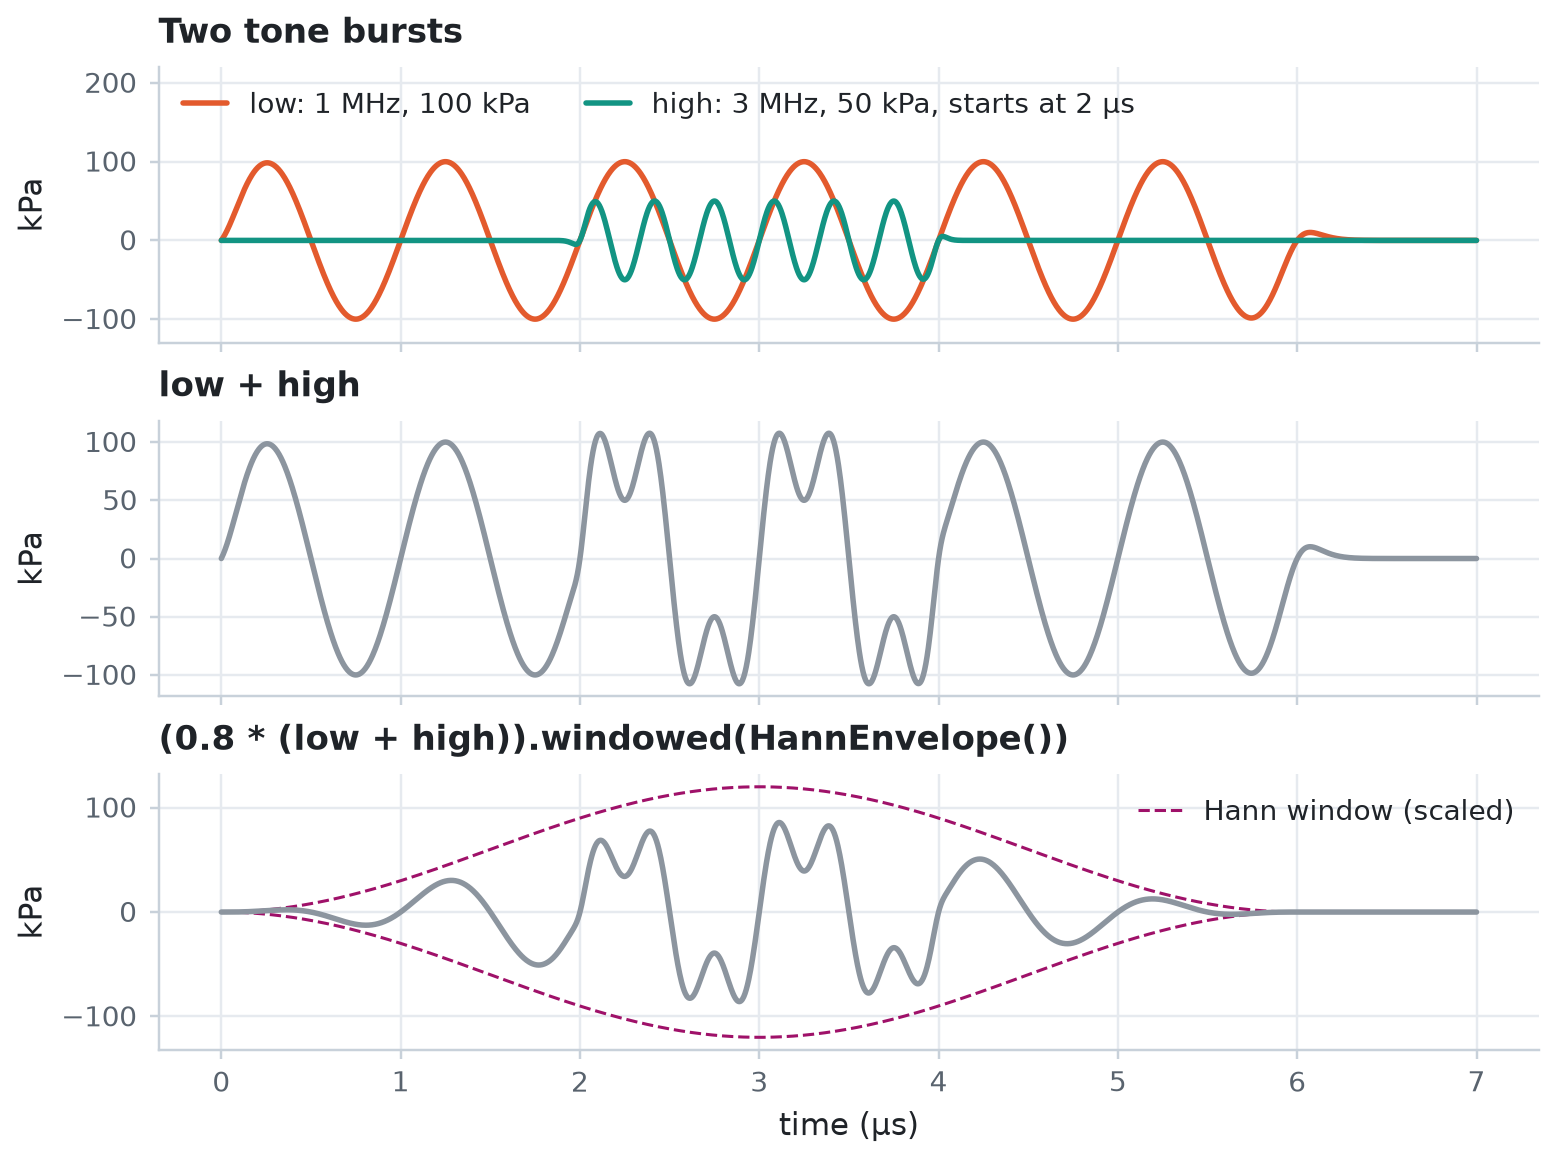

In [3]:
low = ToneBurst(freq=1e6, pressure=100e3, shape=Sine(), cycle_num=6)
high = ToneBurst(freq=3e6, pressure=50e3, shape=Sine(), cycle_num=6, initial_time=2e-6)
mix = low + high
tapered = (0.8 * mix).windowed(HannEnvelope())

for name, p in [("low", low), ("high", high), ("mix", mix), ("tapered", tapered)]:
    print(
        f"{name:8s} {type(p).__name__:9s} active from {p.t_start * 1e6:.1f} to {p.t_stop * 1e6:.1f} µs"
    )

ts = jnp.linspace(0.0, 7e-6, 2000)
t_us = ts * 1e6
fig, axes = plt.subplots(3, 1, figsize=(7.0, 5.2), sharex=True)
axes[0].plot(t_us, jax.vmap(low)(ts) / 1e3, color="C1", label="low: 1 MHz, 100 kPa")
axes[0].plot(
    t_us,
    jax.vmap(high)(ts) / 1e3,
    color="C2",
    label="high: 3 MHz, 50 kPa, starts at 2 µs",
)
axes[0].legend(loc="upper left", ncols=2)
axes[0].set_ylim(-130, 220)  # room for the legend
axes[0].set_title("Two tone bursts")
axes[1].plot(t_us, jax.vmap(mix)(ts) / 1e3, color=DRIVE)
axes[1].set_title("low + high")
envelope = 0.8 * 150 * HannEnvelope()(ts - tapered.t_start, tapered.duration)
axes[2].plot(t_us, envelope, color="C3", lw=1.0, ls="--", label="Hann window (scaled)")
axes[2].plot(t_us, -envelope, color="C3", lw=1.0, ls="--")
axes[2].plot(t_us, jax.vmap(tapered)(ts) / 1e3, color=DRIVE)
axes[2].set_title("(0.8 * (low + high)).windowed(HannEnvelope())")
axes[2].legend(loc="upper right")
axes[2].set_xlabel("time (µs)")
for ax in axes:
    ax.set_ylabel("kPa")
plt.show()

## Sweep the frequency with a chirp

A `ChirpPulse` sweeps its frequency from `freq_start` to `freq_end` over `sweep_duration`, linearly by default. As the sweep passes through a bubble's resonance, the bubble responds most strongly, so a chirp probes a range of frequencies in one pulse.

The bubble below is the `free_bubble` preset: an uncoated 2 µm air bubble in water, which resonates near 2 MHz.

In [4]:
eom, _ = free_bubble(R0=2e-6)
f_start, f_end, sweep = 0.5e6, 4e6, 10e-6
chirp = ChirpPulse(
    freq_start=f_start, freq_end=f_end, pressure=20e3, sweep_duration=sweep
)
chirp_run = run_simulation(eom, chirp, save_spec=SaveSpec(num_samples=2048))

peak = int(jnp.argmax(chirp_run.radius))
t_peak = float(chirp_run.ts[peak])
f_peak = f_start + (f_end - f_start) * t_peak / sweep
print(
    f"Chirp: peak R/R0 = {chirp_run.radius[peak] / eom.R0:.2f} at {t_peak * 1e6:.1f} µs,"
)
print(f"       when the drive frequency is {f_peak / 1e6:.2f} MHz")

Chirp: peak R/R0 = 1.21 at 5.5 µs,
       when the drive frequency is 2.44 MHz


## Load a measured pressure trace

A `SampledPulse` interpolates pressure samples linearly, so you can drive a simulation with a trace recorded by a hydrophone. This example makes a stand-in for a measurement: a 1 MHz pulse whose positive peaks are taller than its negative ones, as after nonlinear propagation, sampled every 25 ns with added noise. `SampledPulse.from_uniform` takes evenly spaced samples and the sample interval.

In [5]:
rng = np.random.default_rng(seed=0)
dt = 25e-9
t_trace = np.arange(0.0, 8e-6, dt)
phase = 2 * np.pi * 1e6 * (t_trace - 4e-6)
gauss = np.exp(-(((t_trace - 4e-6) / 1.2e-6) ** 2))
trace = 100e3 * gauss * (np.sin(phase) - 0.3 * np.cos(2 * phase))
trace += rng.normal(0.0, 3e3, t_trace.size)

measured = SampledPulse.from_uniform(jnp.asarray(trace), dt=dt)
measured_run = run_simulation(eom, measured, save_spec=SaveSpec(num_samples=2048))
print(
    f"Measured trace: {trace.size} samples, peaks of {trace.max() / 1e3:.0f} and {trace.min() / 1e3:.0f} kPa"
)
print(f"                peak R/R0 = {measured_run.radius.max() / eom.R0:.2f}")

Measured trace: 320 samples, peaks of 128 and -74 kPa
                peak R/R0 = 1.23


Plot each drive above the bubble's response. The top axis of the chirp panel shows the frequency of the sweep: the bubble responds most strongly just after the sweep passes its resonance.

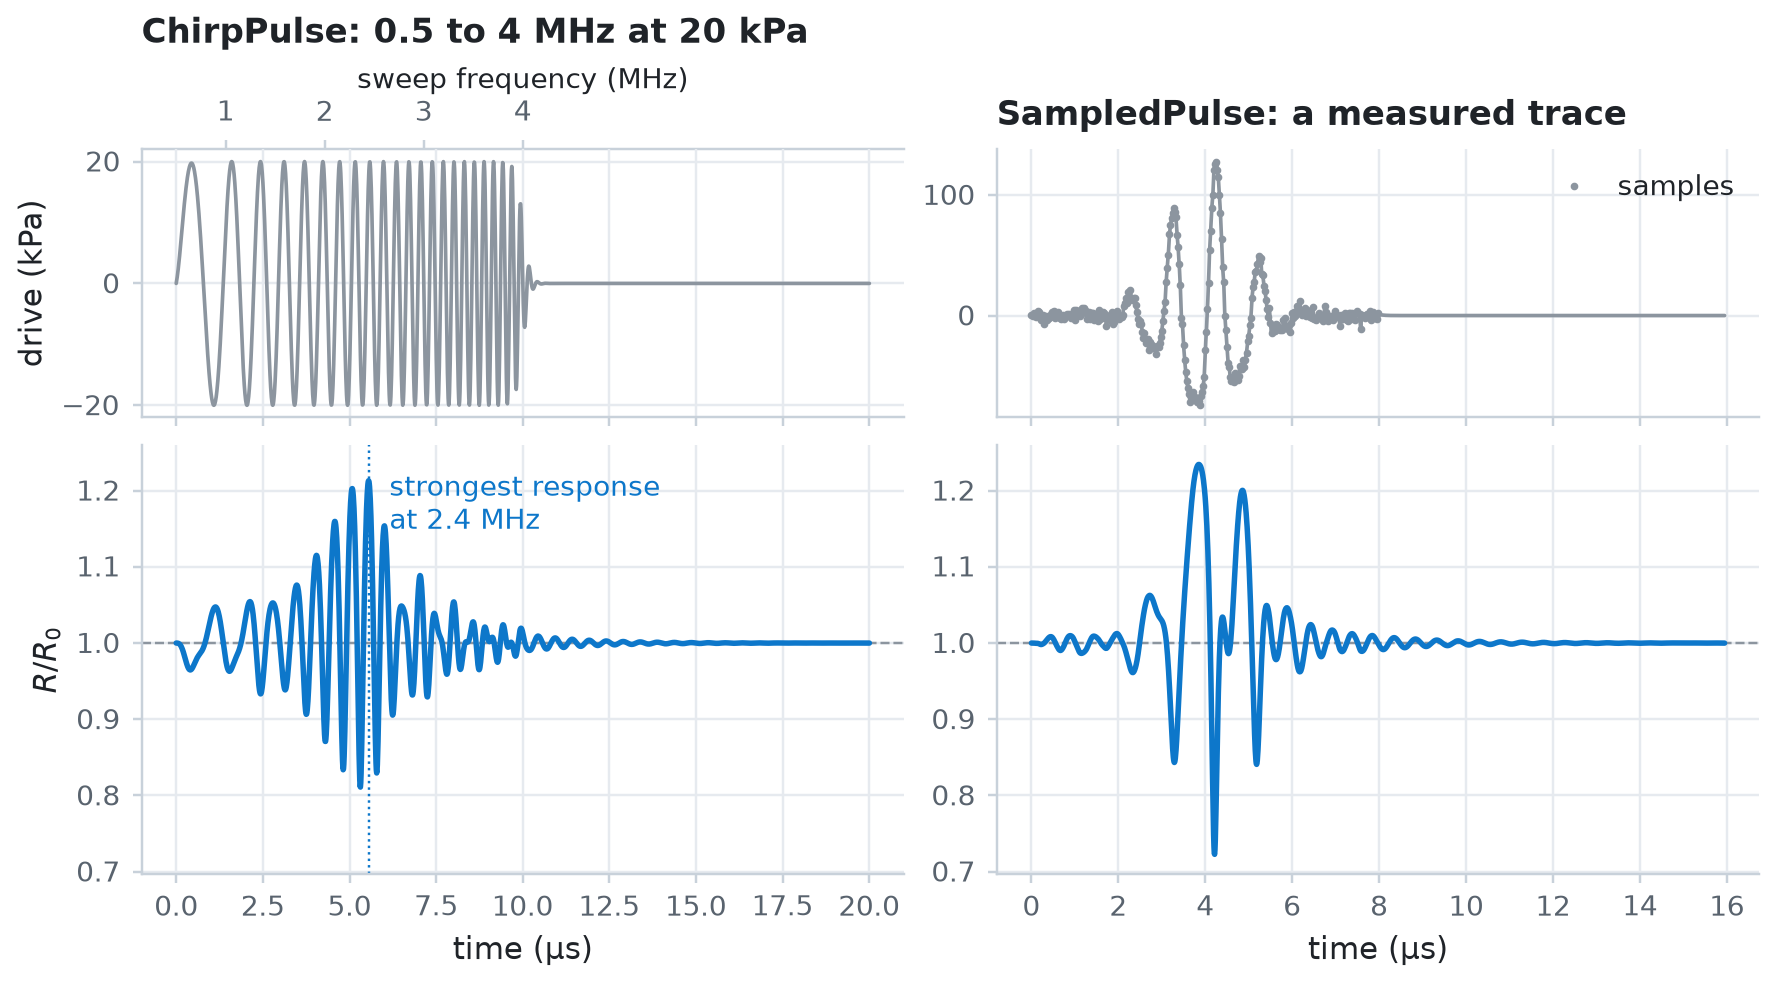

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(8.0, 4.4), sharex="col", height_ratios=[1, 1.6])
axes[1, 1].sharey(axes[1, 0])
for col, (run, title) in enumerate(
    [
        (chirp_run, "ChirpPulse: 0.5 to 4 MHz at 20 kPa"),
        (measured_run, "SampledPulse: a measured trace"),
    ]
):
    t_us = run.ts * 1e6
    axes[0, col].plot(t_us, run.driving_pressure / 1e3, color=DRIVE, lw=1.2)
    axes[0, col].set_title(title)
    axes[1, col].axhline(1.0, color=DRIVE, lw=0.8, ls="--")
    axes[1, col].plot(t_us, run.radius / eom.R0, color="C0")
    axes[1, col].set_xlabel("time (µs)")
axes[0, 0].set_ylabel("drive (kPa)")
axes[1, 0].set_ylabel("$R / R_0$")
axes[0, 1].plot(t_trace * 1e6, trace / 1e3, "o", color=DRIVE, ms=1.5, label="samples")
axes[0, 1].legend(loc="upper right")
to_freq = lambda t: (f_start + (f_end - f_start) * t * 1e-6 / sweep) / 1e6  # noqa: E731
to_time = lambda f: (f * 1e6 - f_start) / (f_end - f_start) * sweep * 1e6  # noqa: E731
top = axes[0, 0].secondary_xaxis("top", functions=(to_freq, to_time))
top.set_xticks([1, 2, 3, 4])
top.set_xlabel("sweep frequency (MHz)", fontsize=9)
axes[1, 0].axvline(t_peak * 1e6, color="C0", lw=0.8, ls=":")
axes[1, 0].text(
    t_peak * 1e6 + 0.6,
    1.15,
    f"strongest response\nat {f_peak / 1e6:.1f} MHz",
    color="C0",
    fontsize=9,
)
plt.show()